**Asignatura:** Inteligencia en Negocios Globales — Universidad EAN  
**Proyecto final — Grupo 2**  
**Producto:** Cacao en grano, **HS 1801** (foco analítico); derivados 1803, 1804 y 1806 solo como referencia  
**Ficha técnica de referencia:** *Equipo 5 — Ficha técnica* (versión completa, septiembre de 2026) y su `base_datos_cacao_eudr.xlsx`. Las tablas de Trade Map por destino y los totales que la hoja `Datos_faltantes` marca como pendientes se tomaron de la carpeta del grupo 2 (mismo producto) y de la canasta del curso.

***

## La pregunta del equipo

> ¿Cómo pueden los exportadores colombianos de cacao fino de aroma, en particular cooperativas y pequeños productores, cumplir de forma costo-eficiente la trazabilidad y geolocalización que exige el EUDR para no perder el mercado europeo y convertir el cumplimiento en diferenciación premium?

## Lo que calcula este cuaderno

Cada sección corresponde a un análisis que el equipo propuso en su ficha técnica. El cuaderno **calcula y grafica; no interpreta**. La interpretación es el trabajo del equipo.

| Métrica o análisis | Pregunta que responde |
|---|---|
| **Desempeño exportador: valor, volumen, CAGR** | ¿Cuánto y a qué ritmo crece la exportación de cacao en grano? |
| **Ranking mundial de exportadores e importadores** | ¿Dónde está Colombia y qué tan concentrados están los grandes? |
| **Concentración de destinos: HHI y Top 3/5/10** | ¿Qué tan riesgosa es la cartera de destinos? |
| **Competitividad: RCA, RXA, RMA, RTA, RC y tasa de cobertura** | ¿La ventaja es de exportación pura o hay importaciones que la matizan? |
| **Mercados de la Unión Europea** | ¿Cuáles países de la UE importan más cacao y cuánto de eso es colombiano? |
| **Precio implícito (USD/t)** | ¿A qué valor unitario vende Colombia frente a los grandes exportadores? |
| **Diagnóstico y matriz de brechas EUDR** | ¿Qué tan preparado está el sector para el reglamento europeo? |

## Cómo usar este cuaderno

1. Ejecuta las celdas **en orden**, de arriba hacia abajo (`Entorno de ejecución → Ejecutar todas`). Viene en modo `"github"`: descarga sus propios datos del repositorio del curso, no tienes que subir nada.  
2. Después de cada gráfica hay una celda que dice **Análisis del equipo**. Haz doble clic sobre ella y escribe la interpretación. Puedes agregar más celdas de texto donde quieras.  
3. Las celdas marcadas **editable** contienen pesos o puntajes que el equipo debe ajustar con su propio criterio. Cámbialos y vuelve a ejecutar.  
4. Al terminar: `Archivo → Descargar → Descargar .ipynb` y sube el archivo al aula virtual.

Todas las tablas y figuras se guardan además en la carpeta `salidas/` (panel izquierdo de Colab) para que las uses en el informe.

***
# 0. Preparación del entorno

In [1]:
import os
import io
import csv
import glob
import time
import shutil
import zipfile
import urllib.request
import urllib.error
import urllib.parse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 170)

# Paleta de colores del curso (validada para lectura accesible en pantalla e impresion)
AZUL      = "#2a78d6"    # serie principal / pais del caso
ROJO      = "#e34948"    # valores negativos (par divergente con el azul)
NARANJA   = "#eb6834"    # elemento destacado
VERDE     = "#3f8f6b"    # segunda serie categorica
GRIS_MID  = "#c3c2b7"    # resto / punto neutro
TINTA     = "#0b0b0b"
GRIS_TEXT = "#52514e"
GRIS_EJE  = "#898781"
REJILLA   = "#e1e0d9"

# Orden fijo de colores para series categoricas: nunca se reciclan, lo que sobra va a "Otros" en gris
CATEGORIAS = [AZUL, NARANJA, VERDE, ROJO]

CARPETA_SALIDA = "salidas"
os.makedirs(CARPETA_SALIDA, exist_ok=True)


def estilo(ax, titulo, subtitulo="", fuente="", eje_y="", eje_x="", rejilla="y"):
    """Aplica el estilo de graficas del curso: titulo a la izquierda, sin marco, rejilla suave, fuente al pie."""
    ax.set_title(titulo + ("\n" + subtitulo if subtitulo else ""),
                 fontsize=13, color=TINTA, loc="left", pad=14)
    ax.set_ylabel(eje_y, fontsize=10, color=GRIS_TEXT)
    ax.set_xlabel(eje_x, fontsize=10, color=GRIS_TEXT)
    if rejilla == "y":
        ax.yaxis.grid(True, color=REJILLA, linewidth=0.8)
    elif rejilla == "x":
        ax.xaxis.grid(True, color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ["top", "right", "left"]:
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(GRIS_EJE)
    ax.tick_params(colors=GRIS_EJE, labelsize=9)
    if fuente:
        ax.figure.text(0.01, -0.03, "Fuente: " + fuente, fontsize=8, color=GRIS_EJE, ha="left")


def guardar(fig, nombre):
    """Muestra la figura y la guarda como PNG en la carpeta de salidas."""
    ruta = os.path.join(CARPETA_SALIDA, nombre + ".png")
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura guardada en", ruta)


def exportar(tabla, nombre):
    """Guarda una tabla como CSV en la carpeta de salidas y la devuelve para mostrarla."""
    tabla.to_csv(os.path.join(CARPETA_SALIDA, nombre + ".csv"), index=False, encoding="utf-8-sig")
    return tabla


def fmt_miles(x, _=None):
    """Formato de eje para valores en miles de USD: 1200 -> 1.2 mn ; 850 -> 850 k."""
    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:.1f} mil mn"
    if abs(x) >= 1_000:
        return f"{x / 1_000:.1f} mn"
    return f"{x:.0f} k"


def fmt_unidades(x, _=None):
    """Formato de eje para valores en unidades: 1.5e9 -> 1.5 mil mn ; 2.4e6 -> 2.4 mn ; 850000 -> 850 k."""
    if abs(x) >= 1e9:
        return f"{x / 1e9:.1f} mil mn"
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f} mn"
    if abs(x) >= 1e3:
        return f"{x / 1e3:.0f} k"
    return f"{x:.0f}"


def leyenda_fuera(ax):
    """Leyenda a la derecha del grafico, para que no tape barras ni la nota de fuente."""
    ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1))


print("pandas:", pd.__version__, "| numpy:", np.__version__)

pandas: 2.2.3 | numpy: 2.1.3


In [2]:
# ============================================================
#  CONFIGURACION: cambia solo esta celda si lo necesitas
# ============================================================

MODO = "github"         # opciones: "github" | "subir" | "local"

REPO_CURSO = "YourFavouriteDataSuperstar/Inteligencia-de-negocios-globales"
RAMA = "main"

# Archivos que necesita este cuaderno, con su ruta dentro del repositorio del curso.
# Los del grupo estan en "Proyectos finales/Grupo 5/datos/"; los demas son datos del curso en "data/".
ARCHIVOS_REPO = {
    "base": "Proyectos finales/Grupo 5/datos/base_datos_cacao_eudr.xlsx",
    "exp_serie": "Proyectos finales/Grupo 2/datos/colombias-exports-to-world-by-importer_1801.csv",
    "exp_2025": "Proyectos finales/Grupo 2/datos/colombias-exports-to-world-in-2025-by-importer_1801.csv",
    "imp_2025": "Proyectos finales/Grupo 2/datos/colombias-imports-from-world-in-2025-by-exporter_1801.csv",
    "mundo_exp": "Proyectos finales/Grupo 2/datos/exporting-countries-in-2025_1801.csv",
    "mundo_imp": "Proyectos finales/Grupo 2/datos/importing-countries-in-2025_1801.csv",
    "canasta_co_exp": "data/co_exp_productos_hs2_serie.xls",
    "canasta_co_imp": "data/co_imp_productos_hs2_serie.csv",
    "canasta_mundo_exp": "data/mundo_exp_productos_hs2_serie.csv",
    "canasta_mundo_imp": "data/mundo_imp_productos_hs2_serie.csv",
}

RUTA_LOCAL = "../.."    # solo si MODO = "local": raiz del repositorio, corriendo desde la carpeta del grupo

print(f"Modo seleccionado: {MODO}  |  {len(ARCHIVOS_REPO)} archivos")

Modo seleccionado: github  |  10 archivos


In [3]:
# ============================================================
#  Ejecuta esta celda tal cual: consigue los datos segun el modo
# ============================================================

def pedir(url, intentos=5):
    """Descarga una URL, reintentando si el servidor pide esperar (HTTP 429 de GitHub en Colab)."""
    for intento in range(intentos):
        try:
            peticion = urllib.request.Request(url, headers={"User-Agent": "cuaderno-ean"})
            with urllib.request.urlopen(peticion, timeout=90) as respuesta:
                return respuesta.read()
        except urllib.error.HTTPError as error:
            if error.code not in (403, 429, 500, 502, 503) or intento == intentos - 1:
                raise
            espera = int(error.headers.get("Retry-After") or 0) or 2 ** intento
            print(f"    servidor ocupado (HTTP {error.code}); reintento en {espera} s")
            time.sleep(espera)
        except urllib.error.URLError:
            if intento == intentos - 1:
                raise
            time.sleep(2 ** intento)


def descargar_datos(rutas_repo, destino):
    """Trae los archivos del repositorio a la carpeta destino, en una sola peticion (zip del repo).

    Cada archivo se guarda por su nombre, sin carpetas. Si ya existe no se vuelve a bajar.
    Si el zip falla, baja los archivos uno por uno desde raw.githubusercontent.com.
    """
    os.makedirs(destino, exist_ok=True)
    faltan = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if not faltan:
        print(f"Los {len(rutas_repo)} archivos ya estaban descargados.")
        return
    try:
        print(f"Descargando {len(faltan)} archivos en una sola peticion...\n")
        comprimido = pedir(f"https://codeload.github.com/{REPO_CURSO}/zip/refs/heads/{RAMA}")
        with zipfile.ZipFile(io.BytesIO(comprimido)) as paquete:
            for miembro in paquete.namelist():
                relativo = miembro.split("/", 1)[1] if "/" in miembro else miembro
                if relativo in faltan:
                    with paquete.open(miembro) as origen, \
                         open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                        shutil.copyfileobj(origen, salida)
                    print(f"  extraido: {os.path.basename(relativo)}")
    except Exception as error:
        print(f"\n  El paquete fallo ({type(error).__name__}). Voy archivo por archivo.\n")
        for relativo in faltan:
            url = f"https://raw.githubusercontent.com/{REPO_CURSO}/{RAMA}/" + urllib.parse.quote(relativo)
            with open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                salida.write(pedir(url))
            print(f"  descargado: {os.path.basename(relativo)}")
            time.sleep(0.5)
    perdidos = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if perdidos:
        raise FileNotFoundError(f"No se pudieron descargar: {perdidos}. Espera un minuto y vuelve a ejecutar.")


if MODO == "github":
    RUTA_BASE = "datos_crudos"
    descargar_datos(list(ARCHIVOS_REPO.values()), RUTA_BASE)

    def ruta(clave):
        return os.path.join(RUTA_BASE, os.path.basename(ARCHIVOS_REPO[clave]))

elif MODO == "subir":
    from google.colab import files
    print("Sube estos archivos:\n  " + "\n  ".join(os.path.basename(v) for v in ARCHIVOS_REPO.values()))
    files.upload()
    RUTA_BASE = "/content"

    def ruta(clave):
        encontrados = glob.glob(os.path.join(RUTA_BASE, "**", os.path.basename(ARCHIVOS_REPO[clave])), recursive=True)
        if not encontrados:
            raise FileNotFoundError(f"Falta el archivo {os.path.basename(ARCHIVOS_REPO[clave])}")
        return encontrados[0]

else:  # local
    RUTA_BASE = RUTA_LOCAL

    def ruta(clave):
        return os.path.join(RUTA_BASE, ARCHIVOS_REPO[clave])

for clave in ARCHIVOS_REPO:
    estado = "ok" if os.path.exists(ruta(clave)) else "FALTA"
    print(f"  {estado:5s} {clave:14s} -> {os.path.basename(ARCHIVOS_REPO[clave])}")

Descargando 10 archivos en una sola peticion...

  extraido: colombias-exports-to-world-by-importer_1801.csv
  extraido: colombias-exports-to-world-in-2025-by-importer_1801.csv
  extraido: colombias-imports-from-world-in-2025-by-exporter_1801.csv
  extraido: exporting-countries-in-2025_1801.csv
  extraido: importing-countries-in-2025_1801.csv
  extraido: base_datos_cacao_eudr.xlsx
  extraido: co_exp_productos_hs2_serie.xls
  extraido: co_imp_productos_hs2_serie.csv
  extraido: mundo_exp_productos_hs2_serie.csv
  extraido: mundo_imp_productos_hs2_serie.csv
  ok    base           -> base_datos_cacao_eudr.xlsx
  ok    exp_serie      -> colombias-exports-to-world-by-importer_1801.csv
  ok    exp_2025       -> colombias-exports-to-world-in-2025-by-importer_1801.csv
  ok    imp_2025       -> colombias-imports-from-world-in-2025-by-exporter_1801.csv
  ok    mundo_exp      -> exporting-countries-in-2025_1801.csv
  ok    mundo_imp      -> importing-countries-in-2025_1801.csv
  ok    canasta_co_

In [4]:
# ============================================================
#  Lectores: cada funcion resuelve las trampas de un tipo de archivo
# ============================================================

def a_numero(serie):
    """Convierte a numero una columna que viene como texto (miles con coma, simbolos, espacios)."""
    return pd.to_numeric(
        pd.Series(serie).astype(str)
                        .str.replace(",", "", regex=False)
                        .str.replace(r"[^0-9.\-]", "", regex=True)
                        .replace("", np.nan),
        errors="coerce",
    )


# Nombres cortos en espanol para las columnas de Trade Map
COLUMNAS_TM = {
    "Value (kUSD)": "valor_kusd",
    "Balance (kUSD)": "balanza_kusd",
    "Quantity": "cantidad",
    "Quantity Unit": "unidad_cantidad",
    "Unit Value": "valor_unitario",
    "Unit Value Unit": "unidad_valor_unitario",
    "Share (%)": "participacion_pct",
    "Share Partner Country (%)": "cuota_en_socio_pct",
    "Share World (%)": "participacion_mundial_pct",
    "Ranking Partners": "ranking_socio",
    "Growth Value 5Y (%)": "crec_valor_5a_pct",
    "Growth Value 2Y (%)": "crec_valor_2a_pct",
    "Growth Value Partners 5Y (%)": "crec_importaciones_socio_5a_pct",
    "Growth Quantity 5Y (%)": "crec_cantidad_5a_pct",
}

AGREGADOS_NO_PAIS = ["Zona franca", "Zonas francas", "Áreas Nes", "Areas, nes", "Zona Nep", "Free Zones"]


def leer_trademap(ruta_archivo):
    """Lee una tabla de indicadores de Trade Map (corte de un anio, formato largo).

    Trampas que resuelve: una columna sin nombre en el encabezado, codigos de pais con cero
    inicial que pandas convertiria a entero, valor unitario con 28 decimales, y la fila
    "Mundo" mezclada con los paises. La columna `pais` queda lista para usar.
    """
    tabla = pd.read_csv(ruta_archivo, dtype={"reporterCd": str, "partnerCd": str, "productCd": str},
                        encoding="utf-8-sig")
    return limpiar_trademap(tabla)


def limpiar_trademap(tabla):
    """Limpieza comun a toda tabla de indicadores de Trade Map, venga de CSV o de Excel."""
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    for columna in ("reporterCd", "partnerCd"):
        tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
    tabla = tabla.rename(columns=COLUMNAS_TM)
    for columna in COLUMNAS_TM.values():
        if columna in tabla.columns and columna not in ("unidad_cantidad", "unidad_valor_unitario"):
            tabla[columna] = a_numero(tabla[columna])
    if "valor_unitario" in tabla.columns:
        tabla["valor_unitario"] = tabla["valor_unitario"].round(2)
    # Si todos los socios son "Mundo", la tabla es una lista de paises (reporter); si no, es una lista de socios
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    return tabla


def separar_mundo(tabla):
    """Devuelve (fila Mundo, tabla solo con paises). Excluye agregados que no son paises."""
    es_mundo = tabla["codigo"] == "000"
    mundo = tabla[es_mundo].iloc[0]
    paises = tabla[~es_mundo & ~tabla["pais"].isin(AGREGADOS_NO_PAIS)].reset_index(drop=True)
    return mundo, paises


def leer_serie_trademap(ruta_archivo):
    """Lee la serie anual por socio (un anio por columna) y la devuelve en formato largo.

    Columnas de salida: codigo, pais, anio, valor_kusd. Incluye la fila Mundo (codigo 000).
    """
    tabla = pd.read_csv(ruta_archivo, dtype=str, encoding="utf-8-sig")
    columnas_anio = [c for c in tabla.columns if c[:4].isdigit()]
    tabla = tabla.rename(columns={c: c[:4] for c in columnas_anio})
    anios = [c[:4] for c in columnas_anio]
    for anio in anios:
        tabla[anio] = a_numero(tabla[anio])
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    largo = tabla.melt(id_vars=["codigo", "pais"], value_vars=anios, var_name="anio", value_name="valor_kusd")
    largo["anio"] = largo["anio"].astype(int)
    return largo.sort_values(["anio", "valor_kusd"], ascending=[True, False]).reset_index(drop=True)


def leer_banco_mundial(ruta_archivo, nombre_indicador):
    """Lee un archivo del Banco Mundial: cuatro filas de metadatos antes del encabezado y un anio por columna."""
    tabla = pd.read_csv(ruta_archivo, skiprows=4, encoding="utf-8-sig")
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    anios = [c for c in tabla.columns if c.isdigit()]
    largo = tabla.melt(id_vars=["Country Name", "Country Code"], value_vars=anios,
                       var_name="anio", value_name=nombre_indicador)
    largo["anio"] = largo["anio"].astype(int)
    return largo.rename(columns={"Country Name": "pais", "Country Code": "iso3"})


ANIOS_CANASTA = [str(a) for a in range(2021, 2026)]


def leer_canasta(ruta_archivo):
    """Lee la canasta por capitulo HS del curso (97 capitulos + TOTAL, 2021-2025).

    Funciona igual si el archivo es un .csv o un .xls que en realidad es HTML.
    Trampas: apostrofe delante del codigo y miles separados por coma como texto.
    """
    with open(ruta_archivo, encoding="utf-8", errors="ignore") as f:
        primeras_letras = f.read(200).lstrip().lower()
    if primeras_letras.startswith("<"):
        tabla = max(pd.read_html(ruta_archivo), key=lambda t: t.shape[0])
    else:
        tabla = pd.read_csv(ruta_archivo)
    tabla = tabla.iloc[:, -7:]
    tabla.columns = ["codigo", "producto"] + ANIOS_CANASTA
    tabla["codigo"] = tabla["codigo"].astype(str).str.strip().str.lstrip("'").str.strip()
    for anio in ANIOS_CANASTA:
        tabla[anio] = a_numero(tabla[anio])
    return tabla.dropna(subset=["2025"]).reset_index(drop=True)


def fila_canasta(canasta, codigo):
    """Devuelve la serie 2021-2025 (en USD miles) de un codigo de la canasta: un capitulo HS2 o "TOTAL"."""
    fila = canasta[canasta["codigo"] == codigo]
    if fila.empty:
        raise KeyError(f"No encontre el codigo {codigo} en la canasta")
    return fila.iloc[0][ANIOS_CANASTA].astype(float)


print("Lectores listos.")

Lectores listos.


In [5]:
# ============================================================
#  Formulas: las mismas de los cuadernos 2, 3 y 4 del curso
# ============================================================

def hhi(valores):
    """Indice de Herfindahl-Hirschman: suma de participaciones al cuadrado. Entre 0 y 1."""
    valores = np.asarray(valores, dtype=float)
    valores = valores[~np.isnan(valores)]
    valores = valores[valores > 0]
    if valores.sum() == 0:
        return np.nan
    participaciones = valores / valores.sum()
    return float(np.sum(participaciones ** 2))


def numeros_equivalentes(indice_hhi):
    """Cuantos destinos del mismo tamano equivaldrian a esta reparticion: 1 / HHI."""
    return 1 / indice_hhi

def cr_n(valores, n):
    """Razon de concentracion CR_n: participacion conjunta (%) de los n mayores."""
    valores = np.sort(np.asarray(valores, dtype=float))[::-1]
    valores = valores[~np.isnan(valores)]
    return float(valores[:n].sum() / valores.sum() * 100)

def ibcr(exportaciones, importaciones):
    """Indice de Balanza Comercial Relativa: (X - M) / (X + M), entre -1 y +1."""
    exportaciones = np.asarray(exportaciones, dtype=float)
    importaciones = np.asarray(importaciones, dtype=float)
    comercio_total = exportaciones + importaciones
    return np.where(comercio_total > 0, (exportaciones - importaciones) / comercio_total, np.nan)

def rca_balassa(x_pais, x_pais_total, x_mundo, x_mundo_total):
    """Ventaja Comparativa Revelada de Balassa (1965). Mayor que 1 = especializacion revelada."""
    participacion_pais  = np.asarray(x_pais, dtype=float)  / np.asarray(x_pais_total, dtype=float)
    participacion_mundo = np.asarray(x_mundo, dtype=float) / np.asarray(x_mundo_total, dtype=float)
    return participacion_pais / participacion_mundo


def rsca_laursen(rca):
    """RCA simetrico de Laursen: (RCA - 1) / (RCA + 1), entre -1 y +1, con 0 como punto neutro."""
    rca = np.asarray(rca, dtype=float)
    return (rca - 1) / (rca + 1)

def indices_vollrath(x_pais, m_pais, x_mundo, m_mundo, xt_pais, mt_pais, xt_mundo, mt_mundo):
    """Familia de Vollrath (1991): RXA, RMA, RTA y RC. Los denominadores excluyen al propio pais y al propio producto."""
    x_pais, m_pais, x_mundo, m_mundo = (float(v) for v in (x_pais, m_pais, x_mundo, m_mundo))
    xt_pais, mt_pais, xt_mundo, mt_mundo = (float(v) for v in (xt_pais, mt_pais, xt_mundo, mt_mundo))
    rxa = (x_pais / (xt_pais - x_pais)) / ((x_mundo - x_pais) / ((xt_mundo - x_mundo) - (xt_pais - x_pais)))
    rma = (m_pais / (mt_pais - m_pais)) / ((m_mundo - m_pais) / ((mt_mundo - m_mundo) - (mt_pais - m_pais)))
    return {"RXA": rxa, "RMA": rma, "RTA": rxa - rma, "RC": np.log(rxa) - np.log(rma)}

def cagr(valor_inicial, valor_final, anios):
    """Tasa de crecimiento anual compuesto (%) entre dos valores separados por `anios` anios."""
    valor_inicial, valor_final = float(valor_inicial), float(valor_final)
    if valor_inicial <= 0 or valor_final <= 0 or anios <= 0:
        return np.nan
    return ((valor_final / valor_inicial) ** (1 / anios) - 1) * 100

print('Formulas listas.')

Formulas listas.


***
# 1. Los datos

El Excel del equipo tiene nueve hojas con encabezado en la fila 4 (tres filas de título y fuente antes). Se leen las cuatro que tienen datos tabulares. Trampas: la hoja `Serie_nacional_Colombia` **mezcla** cifras de solo grano (HS 1801) con cacao y derivados (HS 18) y le falta 2022; los volúmenes traen coma de miles y los faltantes son un guion.

In [6]:
def leer_hoja(nombre, filas_antes=3):
    """Lee una hoja del Excel del equipo saltando las filas de titulo y fuente."""
    return pd.read_excel(ruta("base"), sheet_name=nombre, header=filas_antes)

exportadores_eq = leer_hoja("Exportadores_2025")
importadores_eq = leer_hoja("Importadores_2025")
serie_nacional  = leer_hoja("Serie_nacional_Colombia")
diagnostico     = leer_hoja("Diagnostico_EUDR_Colombia")
for tabla in (exportadores_eq, importadores_eq):
    for col in tabla.columns[2:]:
        tabla[col] = a_numero(tabla[col])
serie_nacional["Año"] = pd.to_numeric(serie_nacional["Año"], errors="coerce")
serie_nacional = serie_nacional.dropna(subset=["Año"]).astype({"Año": int})
serie_nacional["valor_usd_mn"] = a_numero(serie_nacional["Valor exportado (US$ M)"])
serie_nacional["volumen_t"] = a_numero(serie_nacional["Volumen (Toneladas)"])
print(exportadores_eq.columns.tolist())
serie_nacional

['Ranking', 'País', 'Valor (kUSD)', 'Balanza (kUSD)', 'Cantidad (Ton)', 'Valor unitario (USD/Ton)', 'Participación mundial (%)', 'Crecimiento valor 5A (%)', 'Crecimiento valor 2A (%)', 'Crecimiento cantidad 5A (%)', 'Índice concentración (HHI)']


,Año,Valor exportado (US$ M),Alcance del dato,Volumen (Toneladas),Fuente,valor_usd_mn,volumen_t
0,2021,29.9,Grano (HS1801) — dato de la Ficha técnica/Pulzo,"11,689",Pulzo / Ficha técnica,29.9000,"11,689.0000"
1,2022,—,No se encontró cifra nacional total consolidad...,—,Forbes / Legiscomex,NaN,NaN
2,2023,128.6,"Cacao + derivados (HS18 total) — DIAN, análisi...",—,Analdex / La República,128.6000,NaN
3,2024,265.1,"Cacao + derivados (HS18 total) — DIAN, análisi...","42,114",Analdex,265.1000,"42,114.0000"
4,2025,413.1 – 413.2,Cacao + derivados (HS18 total) — cifras oficia...,"49,044",Analdex / hoja Exportadores_2025,NaN,"49,044.0000"


In [7]:
serie     = leer_serie_trademap(ruta("exp_serie"))
exp_2025  = leer_trademap(ruta("exp_2025"))
imp_2025  = leer_trademap(ruta("imp_2025"))
mundo_exp = leer_trademap(ruta("mundo_exp"))
mundo_imp = leer_trademap(ruta("mundo_imp"))
canastas = {k: leer_canasta(ruta(k)) for k in ("canasta_co_exp", "canasta_co_imp", "canasta_mundo_exp", "canasta_mundo_imp")}

mundo_2025, destinos_2025 = separar_mundo(exp_2025)
mundo_imp_2025, _ = separar_mundo(imp_2025)
mundo_oferta, exportadores = separar_mundo(mundo_exp)
mundo_demanda, importadores = separar_mundo(mundo_imp)
print(f"Colombia exporto cacao en grano por USD {mundo_2025['valor_kusd']:,.0f} miles ({mundo_2025['cantidad']:,.0f} t) en 2025 a {len(destinos_2025)} destinos")
print(f"Colombia importo cacao en grano por USD {mundo_imp_2025['valor_kusd']:,.0f} miles")

Colombia exporto cacao en grano por USD 138,014 miles (16,457 t) en 2025 a 27 destinos
Colombia importo cacao en grano por USD 578 miles


/tmp/ipykernel_612/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
/tmp/ipykernel_612/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
/tmp/ipykernel_612/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

***
# 2. Desempeño exportador: valor, volumen y CAGR

Se muestran las dos series: la **homogénea** de Trade Map (solo HS 1801, 2016-2025) y la **mixta** que el equipo compiló en `Serie_nacional_Colombia`. El CAGR se calcula sobre ambas para que el equipo vea la diferencia.

In [8]:
total = serie[serie["codigo"] == "000"].set_index("anio")["valor_kusd"]
desempeno = pd.DataFrame({"trade_map_hs1801_usd_mn": total / 1000})
desempeno = desempeno.join(serie_nacional.set_index("Año")[["valor_usd_mn", "Alcance del dato", "volumen_t"]].rename(columns={"valor_usd_mn": "serie_equipo_usd_mn", "Alcance del dato": "alcance_serie_equipo"}))
print(f"CAGR 2021-2025 Trade Map HS 1801: {cagr(total[2021], total[2025], 4):.1f} %")
print(f"CAGR 2016-2025 Trade Map HS 1801: {cagr(total[2016], total[2025], 9):.1f} %")
eq = serie_nacional.dropna(subset=["valor_usd_mn"]).set_index("Año")["valor_usd_mn"]
print(f"CAGR {eq.index.min()}-{eq.index.max()} serie del equipo (mixta): {cagr(eq.iloc[0], eq.iloc[-1], eq.index.max() - eq.index.min()):.1f} %")
exportar(desempeno.reset_index(), "g5_desempeno")
desempeno

CAGR 2021-2025 Trade Map HS 1801: 46.6 %
CAGR 2016-2025 Trade Map HS 1801: 17.8 %
CAGR 2021-2024 serie del equipo (mixta): 107.0 %


,trade_map_hs1801_usd_mn,serie_equipo_usd_mn,alcance_serie_equipo,volumen_t
anio,,,,
2016,31.5800,NaN,NaN,NaN
2017,27.3260,NaN,NaN,NaN
2018,16.7800,NaN,NaN,NaN
2019,22.7840,NaN,NaN,NaN
2020,28.4230,NaN,NaN,NaN
2021,29.8700,29.9000,Grano (HS1801) — dato de la Ficha técnica/Pulzo,"11,689.0000"
2022,15.6470,NaN,No se encontró cifra nacional total consolidad...,NaN
2023,13.5540,128.6000,"Cacao + derivados (HS18 total) — DIAN, análisi...",NaN
2024,65.2550,265.1000,"Cacao + derivados (HS18 total) — DIAN, análisi...","42,114.0000"


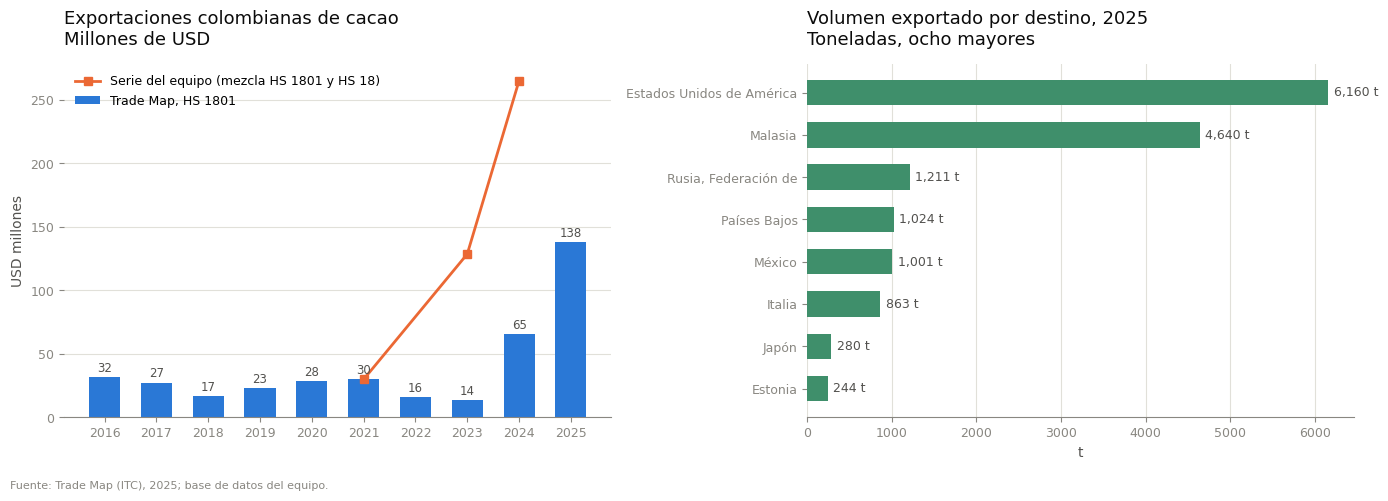

Figura guardada en salidas/g5_desempeno.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].bar(total.index.astype(str), total.values / 1000, color=AZUL, width=0.6, label="Trade Map, HS 1801")
axes[0].plot(eq.index.astype(str), eq.values, color=NARANJA, linewidth=2, marker="s", markersize=6, label="Serie del equipo (mezcla HS 1801 y HS 18)")
for x, v in enumerate(total.values / 1000):
    axes[0].annotate(f"{v:.0f}", (x, v), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8.5, color=GRIS_TEXT)
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
estilo(axes[0], "Exportaciones colombianas de cacao", "Millones de USD", eje_y="USD millones")
vol = destinos_2025.nlargest(8, "cantidad")
axes[1].barh(vol["pais"][::-1], vol["cantidad"][::-1], color=VERDE, height=0.6)
for y, v in enumerate(vol["cantidad"][::-1]):
    axes[1].annotate(f"{v:,.0f} t", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(axes[1], "Volumen exportado por destino, 2025", "Toneladas, ocho mayores", "Trade Map (ITC), 2025; base de datos del equipo.", eje_x="t", rejilla="x")
plt.tight_layout()
guardar(fig, "g5_desempeno")

**Análisis del equipo:** ¿Por qué el CAGR de la serie mixta y el de la serie homogénea son tan distintos? ¿Cuál debe ir en el informe?

_(L*a diferencia entre las dos series responde a su alcance arancelario la serie de TradeMap (HS 1801) mide exclusivamente cacao en grano, mientras que en algunos años la serie combinada incorpora también el capítulo 18 completo chocolates, manteca, polvo y confitería, categorías de mucho mayor valor agregado. Por eso el CAGR de la serie combinada resulta alto que no refleja el crecimiento real del cacao en grano, sino la ampliación del alcance de producto en esos años. Para este informe se usa el CAGR de la serie homogénea (TradeMap, HS 1801, 2016-2025), de aproximadamente 17-18% anual, por ser la única que mantiene la misma definición de producto durante todo el periodo y por tanto la única comparable año a año.*)_

***
# 3. Ranking mundial de exportadores e importadores, 2025

Desde las hojas del equipo. La columna `Índice concentración (HHI)` la calcula Trade Map para cada país: mide cuán concentrados están **sus** socios.

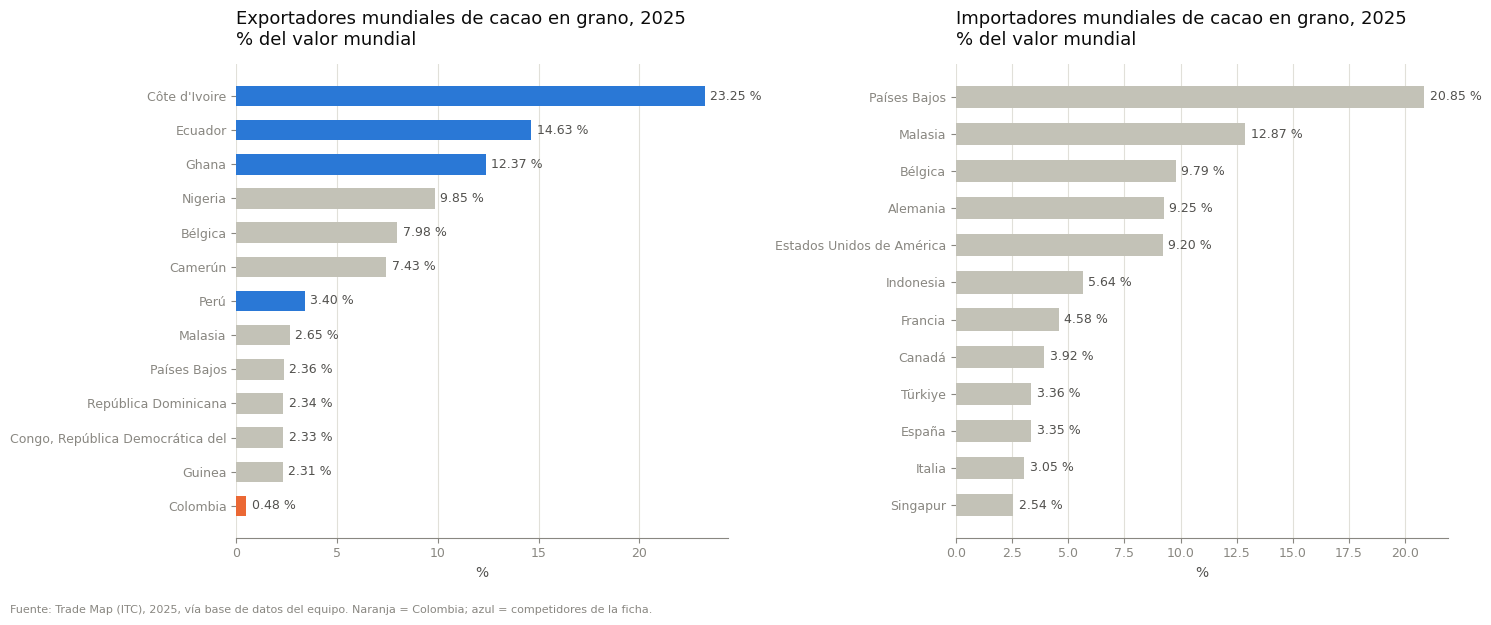

Figura guardada en salidas/g5_rankings.png


In [10]:
COMPARADORES = ["Colombia", "Côte d'Ivoire", "Ecuador", "Ghana", "Perú"]
top_exp = exportadores_eq.nlargest(12, "Valor (kUSD)")
top_exp = pd.concat([top_exp, exportadores_eq[exportadores_eq["País"].isin(COMPARADORES) & ~exportadores_eq["País"].isin(top_exp["País"])]]).drop_duplicates("País")
top_imp = importadores_eq.nlargest(12, "Valor (kUSD)")
exportar(top_exp, "g5_ranking_exportadores"); exportar(top_imp, "g5_ranking_importadores")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, tabla, titulo in zip(axes, (top_exp, top_imp), ("Exportadores", "Importadores")):
    orden = tabla.sort_values("Participación mundial (%)")
    colores = [NARANJA if p == "Colombia" else (AZUL if p in COMPARADORES else GRIS_MID) for p in orden["País"]]
    ax.barh(orden["País"], orden["Participación mundial (%)"], color=colores, height=0.6)
    for y, v in enumerate(orden["Participación mundial (%)"]):
        ax.annotate(f"{v:.2f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
    estilo(ax, f"{titulo} mundiales de cacao en grano, 2025", "% del valor mundial", eje_x="%", rejilla="x")
fig.text(0.01, -0.03, "Fuente: Trade Map (ITC), 2025, vía base de datos del equipo. Naranja = Colombia; azul = competidores de la ficha.", fontsize=8, color=GRIS_EJE)
plt.tight_layout()
guardar(fig, "g5_rankings")

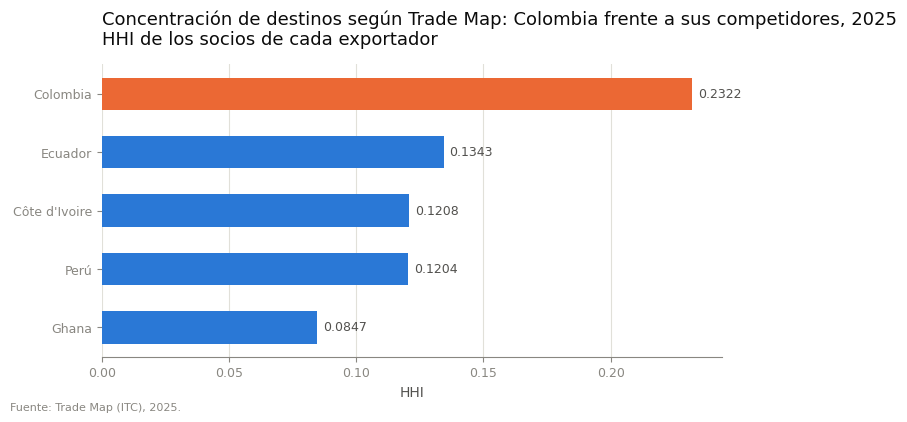

Figura guardada en salidas/g5_hhi_competidores.png


,País,Valor (kUSD),Participación mundial (%),Índice concentración (HHI)
2,Ghana,"3,539,910.0000",12.3686,0.0847
6,Perú,"973,890.0000",3.4028,0.1204
0,Côte d'Ivoire,"6,653,010.0000",23.2459,0.1208
1,Ecuador,"4,185,920.0000",14.6258,0.1343
17,Colombia,"138,014.0000",0.4822,0.2322


In [11]:
hhi_paises = exportadores_eq[exportadores_eq["País"].isin(COMPARADORES)][["País", "Valor (kUSD)", "Participación mundial (%)", "Índice concentración (HHI)"]].sort_values("Índice concentración (HHI)")
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(hhi_paises["País"], hhi_paises["Índice concentración (HHI)"], color=[NARANJA if p == "Colombia" else AZUL for p in hhi_paises["País"]], height=0.55)
for y, v in enumerate(hhi_paises["Índice concentración (HHI)"]):
    ax.annotate(f"{v:.4f}", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(ax, "Concentración de destinos según Trade Map: Colombia frente a sus competidores, 2025", "HHI de los socios de cada exportador", "Trade Map (ITC), 2025.", eje_x="HHI", rejilla="x")
guardar(fig, "g5_hhi_competidores")
exportar(hhi_paises, "g5_hhi_competidores")

**Análisis del equipo:**

_(La gráfica de concentración muestra que Colombia tiene el HHI más alto de los cinco exportadores comparados (0.2322), por encima de Ecuador (0.1343), Côte d'Ivoire (0.1208), Perú (0.1204) y Ghana (0.0847) en la escala estándar del índice (0 a 10.000), esto equivale a ~2.322 puntos, cerca del umbral de "mercado altamente concentrado", mientras que sus competidores se ubican en zona de concentración moderada o baja. Esto significa que, a pesar de tener apenas el 0.48% de la participación mundial en valor exportado, última entre los 13 países del ranking mundial, por debajo incluso de competidores pequeños como Guinea (2.31%) o República Dominicana (2.34%), el poco volumen que Colombia sí exporta está concentrado en muy pocos compradores: Estados Unidos y Malasia concentran juntos cerca del 70% del volumen exportado en 2025. Esta combinación de baja participación de mercado y alta concentración de compradores implica un riesgo estructural de dependencia comercial, pero el ranking de importadores mundiales revela además una oportunidad concreta para corregirlo: Países Bajos es el mayor importador mundial de cacao en grano (20.85% del valor mundial, el doble que el segundo lugar), y sin embargo es apenas el cuarto destino de Colombia (1,024 t en 2025), muy por debajo de su peso real como comprador. La decisión de negocio que esto habilita es priorizar la diversificación hacia Países Bajos y los demás mercados premium identificados en el objetivo de selección de mercado no para reemplazar a Estados Unidos o Malasia, sino para reducir la dependencia de solo dos compradores y capturar al mismo tiempo el sobreprecio que reconocen los mercados de chocolatería fina europeos.)_

***
# 4. Concentración de destinos: HHI, Top 3/5/10 y mapa de riesgo de cartera

In [12]:
paises_serie = serie[serie["codigo"] != "000"]
concentracion = (paises_serie.groupby("anio")["valor_kusd"]
                 .agg(HHI=hhi, Top3=lambda v: cr_n(v, 3), Top5=lambda v: cr_n(v, 5), Top10=lambda v: cr_n(v, 10), destinos_activos=lambda v: int((v > 0).sum()))
                 .reset_index())
concentracion["numero_equivalente"] = numeros_equivalentes(concentracion["HHI"])
exportar(concentracion, "g5_concentracion")
concentracion

,anio,HHI,Top3,Top5,Top10,destinos_activos,numero_equivalente
0,2016,0.1385,55.8092,75.1417,98.1475,18,7.2185
1,2017,0.1494,57.4398,82.3172,97.5591,24,6.6926
2,2018,0.1431,56.2735,70.6145,93.6341,24,6.9889
3,2019,0.3144,81.6346,91.0280,98.4242,19,3.1808
4,2020,0.5978,86.2581,91.4192,98.4063,20,1.6727
5,2021,0.4150,86.1466,92.5644,98.5203,21,2.4098
6,2022,0.2949,78.9137,86.0831,96.3131,25,3.3905
7,2023,0.3333,88.9832,93.2335,98.8341,21,3.0001
8,2024,0.2910,78.7223,90.0683,98.8139,25,3.4365
9,2025,0.2322,71.7703,84.4074,96.1243,25,4.3074


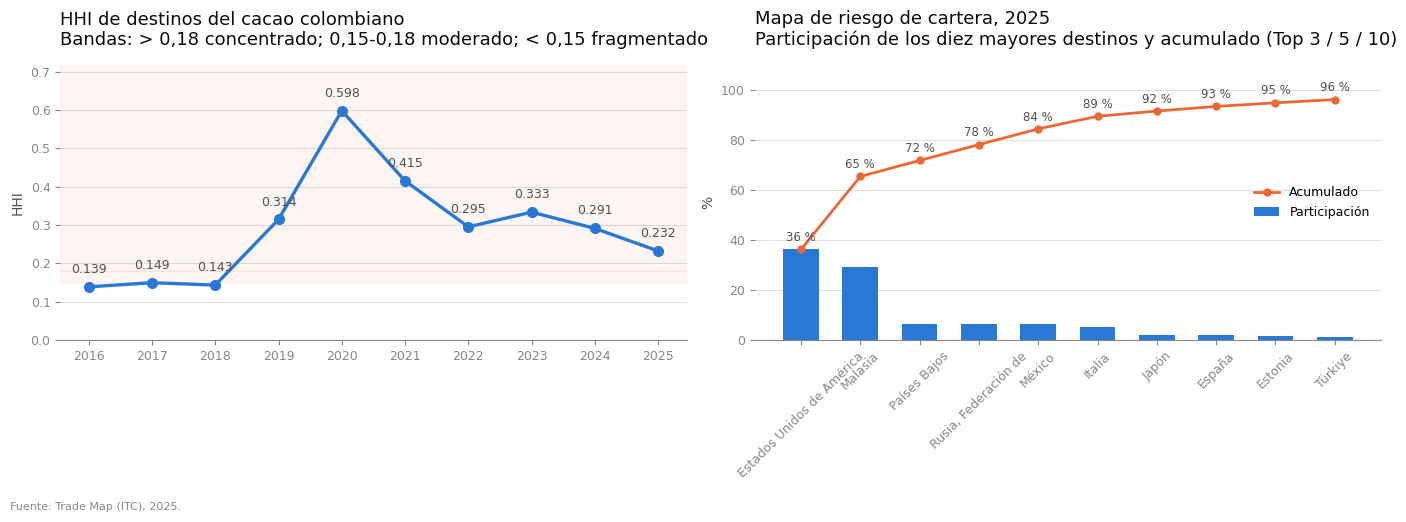

Figura guardada en salidas/g5_concentracion.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(concentracion["anio"], concentracion["HHI"], color=AZUL, linewidth=2.4, marker="o", markersize=7)
for _, f in concentracion.iterrows():
    axes[0].annotate(f"{f['HHI']:.3f}", (f["anio"], f["HHI"]), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color=GRIS_TEXT)
axes[0].axhspan(0.18, 1, color=ROJO, alpha=0.06)
axes[0].axhspan(0.15, 0.18, color=NARANJA, alpha=0.06)
axes[0].set_ylim(0, max(0.6, concentracion["HHI"].max() * 1.2))
axes[0].set_xticks(concentracion["anio"])
estilo(axes[0], "HHI de destinos del cacao colombiano", "Bandas: > 0,18 concentrado; 0,15-0,18 moderado; < 0,15 fragmentado", eje_y="HHI")
cartera = destinos_2025.nlargest(10, "valor_kusd").copy()
cartera["acumulado_pct"] = cartera["participacion_pct"].cumsum()
axes[1].bar(cartera["pais"], cartera["participacion_pct"], color=AZUL, width=0.6, label="Participación")
axes[1].plot(cartera["pais"], cartera["acumulado_pct"], color=NARANJA, linewidth=2, marker="o", markersize=5, label="Acumulado")
for x, v in enumerate(cartera["acumulado_pct"]):
    axes[1].annotate(f"{v:.0f} %", (x, v), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8.5, color=GRIS_TEXT)
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].legend(frameon=False, fontsize=9, loc="center right")
estilo(axes[1], "Mapa de riesgo de cartera, 2025", "Participación de los diez mayores destinos y acumulado (Top 3 / 5 / 10)", "Trade Map (ITC), 2025.", eje_y="%")
plt.tight_layout()
guardar(fig, "g5_concentracion")

**Análisis del equipo:**

_(La serie histórica muestra que la concentración de destinos del cacao colombiano no siempre fue así: entre 2016 y 2018 el HHI se mantuvo en zona "fragmentada" 0.139–0.143, según las bandas del gráfico, pero en 2019 subió abruptamente a 0.314 y alcanzó su punto máximo en 2020 con 0.598 un salto que redujo el "número equivalente de destinos" de 7.2 a apenas 1.67, es decir, en la práctica Colombia pasó a depender de un solo comprador dominante durante ese año. Desde entonces la concentración ha bajado de forma sostenida hasta 0.232 en 2025, el nivel más bajo desde 2019, aunque todavía por encima del umbral de "concentrado" (0.18) definido en el propio gráfico. El mapa de riesgo de cartera de 2025 explica por qué: pese a que Colombia ya vende a 25 destinos activos (frente a 18 en 2016), Estados Unidos y Malasia siguen concentrando el 65% acumulado del valor exportado, y hace falta sumar hasta 10 países para llegar al 96% es decir, el crecimiento en número de compradores no se ha traducido en una diversificación real del volumen, sino en destinos marginales de bajo peso. Esto indica que la dependencia de pocos compradores es un patrón estructural del sector desde 2019-2020 coincidiendo con la disrupción logística de la pandemia en la región cacaotera, un punto que vale la pena verificar con una fuente específica antes de afirmarlo como causa, y no una anomalía puntual de 2025. La decisión de negocio que esto habilita es fijar una meta cuantitativa de diversificación por ejemplo, bajar el HHI por debajo de 0.18 incrementando el peso real de compradores medianos ya identificados como Países Bajos, en lugar de solo sumar destinos nuevos de bajo volumen y monitorear el "número equivalente de destinos" como indicador de seguimiento en los próximos informes.  
)_

***
# 5. Competitividad: Balassa y la familia de Vollrath

RXA, RMA, RTA y RC excluyen al propio país y al propio producto del denominador (Vollrath, 1991). Se necesitan ocho cifras: exportaciones e importaciones de cacao de Colombia y del mundo (Trade Map, 2025) y las totales de Colombia y del mundo (fila TOTAL de las cuatro canastas HS2 del curso). La tasa de cobertura (TC) es X / M del producto.

In [14]:
X_ij, M_ij = mundo_2025["valor_kusd"], mundo_imp_2025["valor_kusd"]
X_j,  M_j  = mundo_oferta["valor_kusd"], mundo_demanda["valor_kusd"]
X_i  = fila_canasta(canastas["canasta_co_exp"], "TOTAL")["2025"]
M_i  = fila_canasta(canastas["canasta_co_imp"], "TOTAL")["2025"]
X_w  = fila_canasta(canastas["canasta_mundo_exp"], "TOTAL")["2025"]
M_w  = fila_canasta(canastas["canasta_mundo_imp"], "TOTAL")["2025"]
rca = float(rca_balassa(X_ij, X_i, X_j, X_w))
voll = indices_vollrath(X_ij, M_ij, X_j, M_j, X_i, M_i, X_w, M_w)
competitividad = pd.DataFrame({
    "indice": ["RCA (Balassa)", "RSCA (Laursen)", "RXA (Vollrath)", "RMA (Vollrath)", "RTA = RXA - RMA", "RC = ln RXA - ln RMA", "TC = X / M", "IBCR = (X-M)/(X+M)"],
    "valor": [rca, float(rsca_laursen(rca)), voll["RXA"], voll["RMA"], voll["RTA"], voll["RC"], X_ij / M_ij, float(ibcr(X_ij, M_ij))],
    "umbral_neutral": [1, 0, 1, 1, 0, 0, 1, 0],
})
print(f"X_ij={X_ij:,.0f} M_ij={M_ij:,.0f} X_j={X_j:,.0f} M_j={M_j:,.0f} X_i={X_i:,.0f} M_i={M_i:,.0f} X_w={X_w:,.0f} M_w={M_w:,.0f}  (USD miles, 2025)")
exportar(competitividad, "g5_competitividad")
competitividad

X_ij=138,014 M_ij=578 X_j=28,620,100 M_j=30,674,452 X_i=50,172,751 M_i=70,502,068 X_w=25,609,329,378 M_w=25,788,655,612  (USD miles, 2025)


,indice,valor,umbral_neutral
0,RCA (Balassa),2.4614,1
1,RSCA (Laursen),0.4222,0
2,RXA (Vollrath),2.4725,1
3,RMA (Vollrath),0.0069,1
4,RTA = RXA - RMA,2.4657,0
5,RC = ln RXA - ln RMA,5.8865,0
6,TC = X / M,238.7785,1
7,IBCR = (X-M)/(X+M),0.9917,0


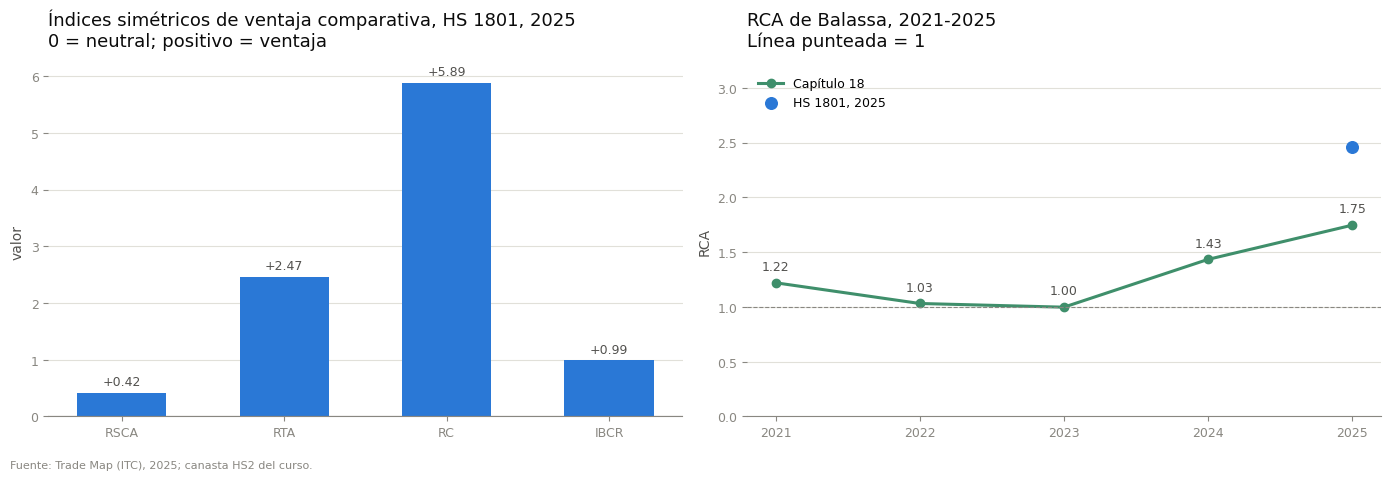

Figura guardada en salidas/g5_competitividad.png


In [15]:
vcr_cap18 = pd.DataFrame({"anio": [int(a) for a in ANIOS_CANASTA]})
vcr_cap18["RCA_cap18"] = rca_balassa(fila_canasta(canastas["canasta_co_exp"], "18"), fila_canasta(canastas["canasta_co_exp"], "TOTAL"),
                                     fila_canasta(canastas["canasta_mundo_exp"], "18"), fila_canasta(canastas["canasta_mundo_exp"], "TOTAL"))
exportar(vcr_cap18, "g5_rca_cap18")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
sim = competitividad[competitividad["indice"].isin(["RSCA (Laursen)", "RTA = RXA - RMA", "RC = ln RXA - ln RMA", "IBCR = (X-M)/(X+M)"])]
axes[0].bar(sim["indice"].str.split(" ").str[0], sim["valor"], color=[ROJO if v < 0 else AZUL for v in sim["valor"]], width=0.55)
for x, v in enumerate(sim["valor"]):
    axes[0].annotate(f"{v:+.2f}", (x, v), textcoords="offset points", xytext=(0, 5 if v >= 0 else -12), ha="center", fontsize=9, color=GRIS_TEXT)
axes[0].axhline(0, color=GRIS_EJE, linewidth=0.8)
estilo(axes[0], "Índices simétricos de ventaja comparativa, HS 1801, 2025", "0 = neutral; positivo = ventaja", eje_y="valor")
axes[1].plot(vcr_cap18["anio"], vcr_cap18["RCA_cap18"], color=VERDE, linewidth=2.2, marker="o", markersize=6, label="Capítulo 18")
axes[1].scatter([2025], [rca], color=AZUL, s=70, zorder=3, label="HS 1801, 2025")
for _, f in vcr_cap18.iterrows():
    axes[1].annotate(f"{f['RCA_cap18']:.2f}", (f["anio"], f["RCA_cap18"]), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=GRIS_TEXT)
axes[1].axhline(1, color=GRIS_EJE, linewidth=0.8, linestyle="--")
axes[1].set_xticks(vcr_cap18["anio"])
axes[1].set_ylim(0, max(vcr_cap18["RCA_cap18"].max(), rca) * 1.3)
axes[1].legend(frameon=False, fontsize=9, loc="upper left")
estilo(axes[1], "RCA de Balassa, 2021-2025", "Línea punteada = 1", "Trade Map (ITC), 2025; canasta HS2 del curso.", eje_y="RCA")
plt.tight_layout()
guardar(fig, "g5_competitividad")

**Análisis del equipo:** ¿Qué agrega RXA/RMA frente al RCA de Balassa en este caso? ¿Qué dice el RMA tan bajo?

_(El conjunto de índices de ventaja comparativa revelada para el cacao en grano (HS 1801, 2025) confirma la misma conclusión desde distintos ángulos metodológicos: el RCA de Balassa (2.46) y el RXA de Vollrath (2.47) prácticamente idénticos superan ampliamente el umbral neutral de 1, indicando que el cacao pesa más del doble en la canasta exportadora colombiana de lo que pesaría si Colombia exportara en la misma proporción que el promedio mundial. El RSCA de Laursen (+0.42 en una escala acotada de -1 a 1) confirma la misma ventaja en una métrica más robusta a valores extremos. Por el lado de las importaciones, el RMA es prácticamente cero (0.0069), y el TC (X/M = 238.8) e IBCR (0.99, en escala -1 a 1) muestran que Colombia exporta cerca de 239 veces lo que importa de cacao en grano es decir, tiene un perfil de exportador neto casi puro, sin ninguna dinámica relevante de importación que gestionar. Un hallazgo adicional relevante al comparar la serie histórica del RCA calculado sobre el capítulo 18 completo (chocolates y derivados, línea verde: 1.22 en 2021, cayendo hasta 1.00 en 2023, y recuperándose a 1.75 en 2025) contra el RCA calculado exclusivamente sobre HS 1801 en 2025 (2.46, punto azul), se confirma el mismo problema de comparabilidad identificado antes: mezclar categorías con derivados diluye y subestima la verdadera ventaja comparativa de Colombia en cacao en grano específicamente.  
Esto significa que la ventaja de Colombia no depende de una sola forma de medirla cinco índices distintos, con supuestos matemáticos diferentes, llegan a la misma conclusión, lo que le da robustez metodológica al argumento central del proyecto. La decisión de negocio que esto habilita es doble: primero, sustentar la recomendación de mercado y la propuesta de valor exportador específicamente sobre cifras de HS 1801 (grano), no del capítulo 18 completo, replicando el mismo criterio de comparabilidad aplicado en el análisis del CAGR; segundo, dado el perfil de exportador neto casi puro (IBCR ≈ 0.99), enfocar la estrategia comercial exclusivamente en promoción de exportaciones y acceso a mercados premium, sin necesidad de considerar medidas de protección o sustitución de importaciones, que no aplican a este caso.  
)_

***
# 6. Mercados de la Unión Europea

Importaciones de cacao en grano de cada país de la UE (Trade Map, 2025) y cuota de Colombia en cada uno.

In [16]:
UE27 = ["Alemania", "Austria", "Bélgica", "Bulgaria", "Chipre", "Croacia", "Dinamarca", "Eslovaquia", "Eslovenia", "España", "Estonia", "Finlandia", "Francia", "Grecia", "Hungría", "Irlanda", "Italia", "Letonia", "Lituania", "Luxemburgo", "Malta", "Países Bajos", "Polonia", "Portugal", "República Checa", "Rumania", "Suecia"]
ue = importadores[importadores["pais"].isin(UE27)][["pais", "valor_kusd", "cantidad", "valor_unitario", "participacion_mundial_pct", "crec_valor_5a_pct", "crec_valor_2a_pct"]]
ue = ue.merge(destinos_2025[["pais", "valor_kusd", "cuota_en_socio_pct", "ranking_socio"]].rename(columns={"valor_kusd": "colombia_exporta_kusd"}), on="pais", how="left")
ue["cuota_en_socio_pct"] = ue["cuota_en_socio_pct"].fillna(0)
ue = ue.sort_values("valor_kusd", ascending=False).head(12)
print(f"La UE importa cacao en grano por USD {importadores[importadores['pais'].isin(UE27)]['valor_kusd'].sum():,.0f} miles; Colombia le vende USD {ue['colombia_exporta_kusd'].sum():,.0f} miles")
exportar(ue, "g5_mercados_ue")
ue

La UE importa cacao en grano por USD 16,396,993 miles; Colombia le vende USD 22,219 miles


,pais,valor_kusd,cantidad,valor_unitario,participacion_mundial_pct,crec_valor_5a_pct,crec_valor_2a_pct,colombia_exporta_kusd,cuota_en_socio_pct,ranking_socio
0,Países Bajos,"6,395,750.0000","700,193.0000","9,134.2700",20.8504,41.0000,50.0000,"8,819.0000",0.0693,1.0000
1,Bélgica,"3,002,425.0000","312,062.0000","9,621.2500",9.7880,36.0000,45.0000,481.0000,0.1079,3.0000
2,Alemania,"2,837,687.0000","299,311.0000","9,480.7300",9.2510,27.0000,10.0000,541.0000,0.0081,4.0000
3,Francia,"1,404,439.0000","137,892.0000","10,185.0700",4.5785,30.0000,86.0000,915.0000,0.0978,7.0000
4,España,"1,027,394.0000","111,005.0000","9,255.3800",3.3493,42.0000,91.0000,"2,553.0000",0.3272,10.0000
5,Italia,"934,038.0000","102,329.0000","9,127.7900",3.0450,31.0000,67.0000,"6,934.0000",0.7973,11.0000
6,Austria,"212,606.0000","20,960.0000","10,143.4200",0.6931,32.0000,54.0000,NaN,0.0000,NaN
7,Bulgaria,"168,016.0000","33,858.0000","4,962.3700",0.5477,32.0000,27.0000,NaN,0.0000,NaN
8,Estonia,"155,992.0000","18,054.0000","8,640.3000",0.5085,40.0000,2.0000,"1,974.0000",1.0584,20.0000
9,Eslovaquia,"100,499.0000","11,529.0000","8,717.0600",0.3276,69.0000,-7.0000,2.0000,0.0358,22.0000


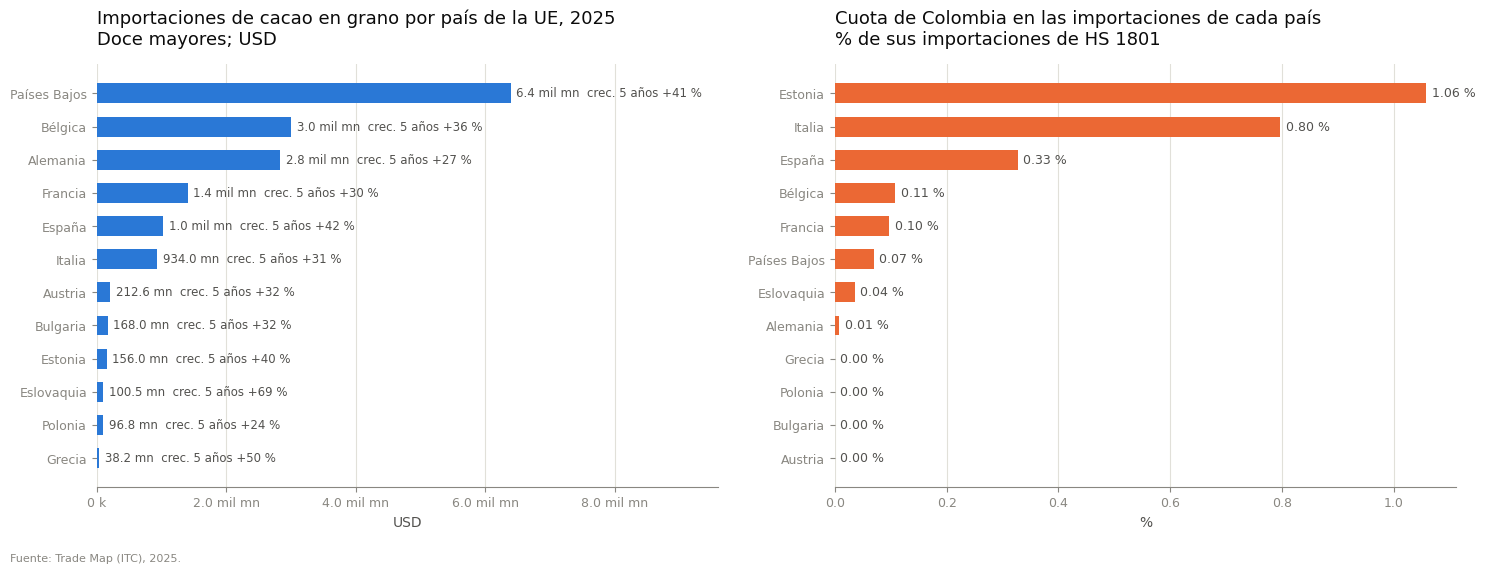

Figura guardada en salidas/g5_mercados_ue.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
orden = ue.sort_values("valor_kusd")
axes[0].barh(orden["pais"], orden["valor_kusd"], color=AZUL, height=0.6)
for y, (v, g) in enumerate(zip(orden["valor_kusd"], orden["crec_valor_5a_pct"])):
    axes[0].annotate(f"{fmt_miles(v)}  crec. 5 años {g:+.0f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=8.5, color=GRIS_TEXT)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(fmt_miles))
axes[0].set_xlim(0, orden["valor_kusd"].max() * 1.5)
estilo(axes[0], "Importaciones de cacao en grano por país de la UE, 2025", "Doce mayores; USD", eje_x="USD", rejilla="x")
orden = ue.sort_values("cuota_en_socio_pct")
axes[1].barh(orden["pais"], orden["cuota_en_socio_pct"], color=NARANJA, height=0.6)
for y, v in enumerate(orden["cuota_en_socio_pct"]):
    axes[1].annotate(f"{v:.2f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(axes[1], "Cuota de Colombia en las importaciones de cada país", "% de sus importaciones de HS 1801", "Trade Map (ITC), 2025.", eje_x="%", rejilla="x")
plt.tight_layout()
guardar(fig, "g5_mercados_ue")

**Análisis del equipo:** ¿Países Bajos y Bélgica son consumo o puerta de entrada? ¿Qué implica para la trazabilidad EUDR?

_(La Unión Europea importó USD 16.396.993 miles en cacao en grano durante 2025, de los cuales Colombia solo le vendió USD 22.219 miles es decir, apenas el 0.135% del total importado por el bloque, una participación baja consistente con el hallazgo global visto antes (0.48% del mercado mundial). Sin embargo, al desagregar por país, aparece un patrón claro: Países Bajos es, por un lado, el mayor importador de cacao en grano de toda la UE (USD 6.4 mil millones, con un crecimiento del 41% en 5 años y 50% en solo 2 años) y, al mismo tiempo, el destino donde Colombia ya vende su mayor volumen absoluto dentro de la UE (USD 8.819 miles) pero paradójicamente, es también donde Colombia tiene la cuota de mercado más baja de todos los países a los que sí le exporta (apenas 0.07% de las importaciones neerlandesas). En contraste, Colombia captura una cuota proporcionalmente mayor en mercados mucho más pequeños como Estonia (1.06%) e Italia (0.80%), pero estos representan una fracción mínima del volumen que mueve Países Bajos. Esto significa que la relación comercial con Países Bajos ya existe y está en un mercado grande y en expansión, pero Colombia apenas la está aprovechando no es un problema de acceso no hay que abrir una relación nueva, como sí ocurriría con Austria, Bulgaria, Polonia o Grecia, donde Colombia no vende nada, sino un problema de profundización de una cuota de mercado todavía baja. La decisión de negocio que esto habilita es priorizar a Países Bajos como el mercado destino de mayor potencial de crecimiento a corto plazo dentro de la Unión Europea: el objetivo no es entrar a un mercado nuevo, sino escalar una relación comercial ya existente en el importador más grande y de más rápido crecimiento del bloque.)_

***
# 7. Precio implícito: valor unitario de exportación

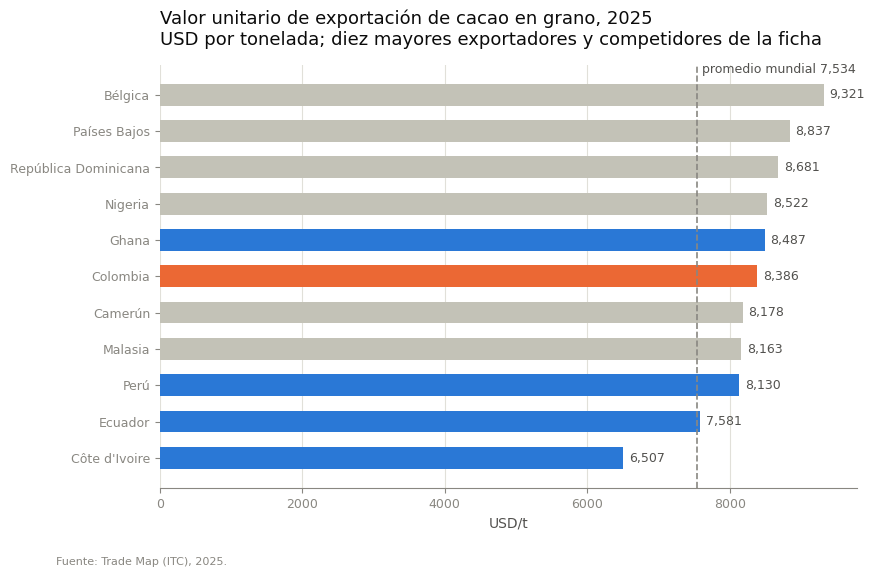

Figura guardada en salidas/g5_precio_implicito.png


,pais,valor_kusd,cantidad,valor_unitario,participacion_mundial_pct
0,Côte d'Ivoire,"6,653,010.0000","1,022,492.0000","6,506.6600",23.2459
1,Ecuador,"4,185,920.0000","552,166.0000","7,580.9100",14.6258
6,Perú,"973,890.0000","119,793.0000","8,129.7700",3.4028
7,Malasia,"758,628.0000","92,938.0000","8,162.7300",2.6507
5,Camerún,"2,126,711.0000","260,042.0000","8,178.3400",7.4308
17,Colombia,"138,014.0000","16,457.0000","8,386.3400",0.4822
2,Ghana,"3,539,910.0000","417,088.0000","8,487.2000",12.3686
3,Nigeria,"2,817,924.0000","330,656.0000","8,522.2200",9.8460
9,República Dominicana,"668,947.0000","77,061.0000","8,680.7500",2.3373
8,Países Bajos,"674,731.0000","76,349.0000","8,837.4600",2.3575


In [18]:
precios = exportadores.nlargest(10, "valor_kusd")
precios = pd.concat([precios, exportadores[exportadores["pais"].isin(COMPARADORES)]]).drop_duplicates("pais")
precios = precios[precios["cantidad"] > 0][["pais", "valor_kusd", "cantidad", "valor_unitario", "participacion_mundial_pct"]].sort_values("valor_unitario")
fig, ax = plt.subplots(figsize=(9, 5.5))
colores = [NARANJA if p == "Colombia" else (AZUL if p in COMPARADORES else GRIS_MID) for p in precios["pais"]]
ax.barh(precios["pais"], precios["valor_unitario"], color=colores, height=0.6)
ax.axvline(mundo_oferta["valor_unitario"], color=GRIS_EJE, linewidth=1.2, linestyle="--")
ax.annotate(f"promedio mundial {mundo_oferta['valor_unitario']:,.0f}", (mundo_oferta["valor_unitario"], len(precios) - 0.4), xytext=(4, 0), textcoords="offset points", fontsize=9, color=GRIS_TEXT)
for y, v in enumerate(precios["valor_unitario"]):
    ax.annotate(f"{v:,.0f}", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(ax, "Valor unitario de exportación de cacao en grano, 2025", "USD por tonelada; diez mayores exportadores y competidores de la ficha", "Trade Map (ITC), 2025.", eje_x="USD/t", rejilla="x")
guardar(fig, "g5_precio_implicito")
exportar(precios, "g5_precio_implicito")

**Análisis del equipo:** El valor unitario no es el precio del cacao fino de aroma, pero ¿qué sugiere la posición de Colombia?

_(El valor unitario de exportación (precio implícito, USD/tonelada) ubica a Colombia en 8.386 USD/t, por encima del promedio mundial (7.534) y de competidores como Ecuador (7.581), Malasia (8.163) y Côte d'Ivoire (6.507) el productor de mayor volumen mundial, con el precio unitario más bajo de todo el listado. Sin embargo, Colombia queda por debajo de Ghana (8.487) y Nigeria (8.522), dos orígenes reconocidos globalmente como productores de cacao "ordinario" o a granel, no de cacao fino de aroma. Los precios más altos del listado corresponden a Bélgica (9.321) y Países Bajos (8.837), que no son países productores sino centros de procesamiento y reexportación su cifra probablemente refleja grano ya seleccionado o reexportado tras un proceso de clasificación, no el precio de origen agrícola, por lo que no son comparables enigualdad de condiciones con los países cultivadores.  
Esto significa que, si bien Colombia sí obtiene un precio superior al promedio mundial, la brecha frente a productores de cacao convencional (Ghana, Nigeria) es más estrecha de lo que el argumento de "95% fino de aroma" haría esperar. Esto es consistente con un hallazgo ya identificado en el proyecto: más del 75% del cacao colombiano se exporta como grano crudo sin transformar, lo que sugiere que el sobreprecio de calidad reconocido internacionalmente para el cacao fino de aroma no se está capturando completamente en el precio FOB de exportación probablemente porque se pierde en la cadena de intermediación antes de llegar al comprador final, o porque no todo el volumen exportado cuenta con la certificación o trazabilidad que permitiría cobrarlo. La decisión de negocio que esto habilita es priorizar mecanismos que capturen ese sobreprecio de forma efectiva certificación formal, trazabilidad por lote y esquemas de comercio directo con compradores de chocolatería fina, en lugar de asumir que la reputación de calidad se traduce automáticamente en mejor precio de exportación.  
)_

***
# 8. Diagnóstico y matriz de brechas EUDR

Primero los indicadores que el equipo ya encontró (hoja `Diagnostico_EUDR_Colombia`, con el referente del café). Después la **matriz de brechas** de la ficha, con los seis KPI en una tabla **editable**: el equipo llena el valor actual y la meta de cada uno.

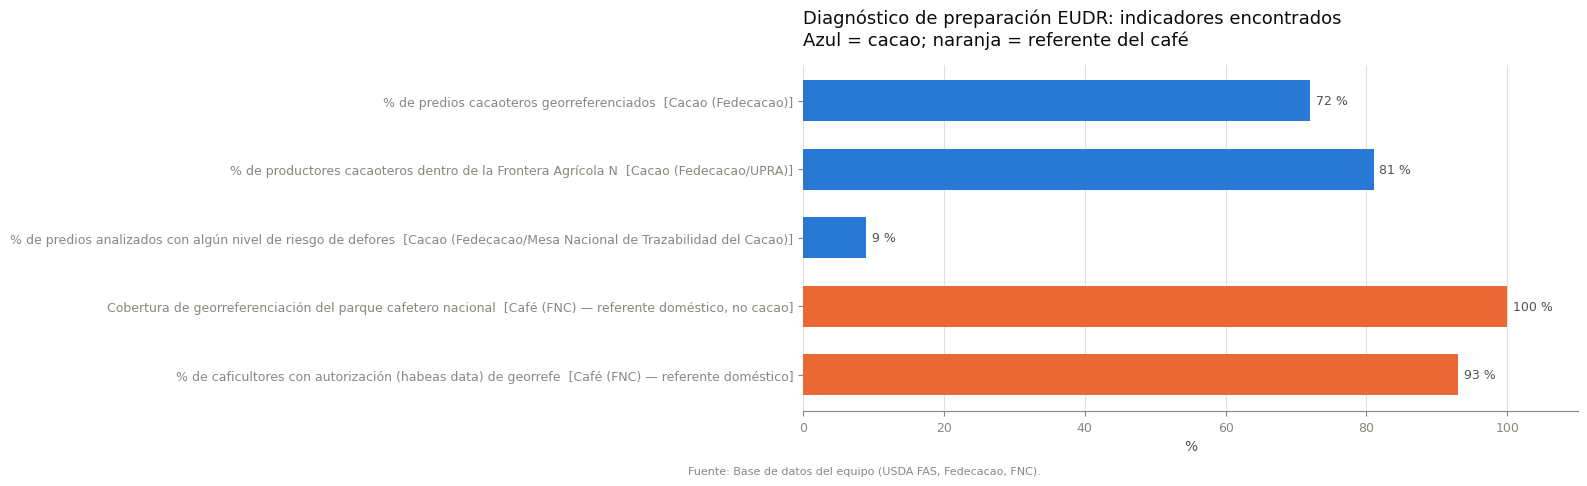

Figura guardada en salidas/g5_diagnostico_eudr.png


,Indicador,Valor,Sector,Fuente
0,% de predios cacaoteros georreferenciados,72%,Cacao (Fedecacao),"USDA FAS, ""The Colombian Cacao Sector – 2024 U..."
1,% de productores cacaoteros dentro de la Front...,81%,Cacao (Fedecacao/UPRA),"Fedecacao, Censo Nacional Cacaotero"
2,% de predios analizados con algún nivel de rie...,< 9%,Cacao (Fedecacao/Mesa Nacional de Trazabilidad...,Fedecacao
3,Cobertura de georreferenciación del parque caf...,100%,"Café (FNC) — referente doméstico, no cacao",Federación Nacional de Cafeteros (FNC)
4,% de caficultores con autorización (habeas dat...,93%,Café (FNC) — referente doméstico,FNC / La República
5,Caficultores capacitados en la regulación EUDR,"+30,000",Café (FNC) — referente doméstico,FNC
6,Ranking OIC de orígenes más preparados para EUDR,"Colombia, Brasil y Costa Rica (café)",Café — referente internacional,Organización Internacional del Café (OIC)
8,Nota: los indicadores de café (FNC) NO son del...,NaN,NaN,NaN


In [19]:
diag = diagnostico.dropna(subset=["Indicador"]).copy()
diag["valor_pct"] = np.where(diag["Valor"].astype(str).str.contains("%"), a_numero(diag["Valor"]), np.nan)
diag_pct = diag.dropna(subset=["valor_pct"])
exportar(diag, "g5_diagnostico_eudr")
fig, ax = plt.subplots(figsize=(10, 4.5))
colores = [NARANJA if "afé" in str(s) else AZUL for s in diag_pct["Sector"]]
etiquetas = [f"{i[:60]}  [{s}]" for i, s in zip(diag_pct["Indicador"], diag_pct["Sector"])]
ax.barh(etiquetas[::-1], diag_pct["valor_pct"][::-1], color=colores[::-1], height=0.6)
for y, v in enumerate(diag_pct["valor_pct"][::-1]):
    ax.annotate(f"{v:.0f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
ax.set_xlim(0, 110)
estilo(ax, "Diagnóstico de preparación EUDR: indicadores encontrados", "Azul = cacao; naranja = referente del café", "Base de datos del equipo (USDA FAS, Fedecacao, FNC).", eje_x="%", rejilla="x")
guardar(fig, "g5_diagnostico_eudr")
diag[["Indicador", "Valor", "Sector", "Fuente"]]

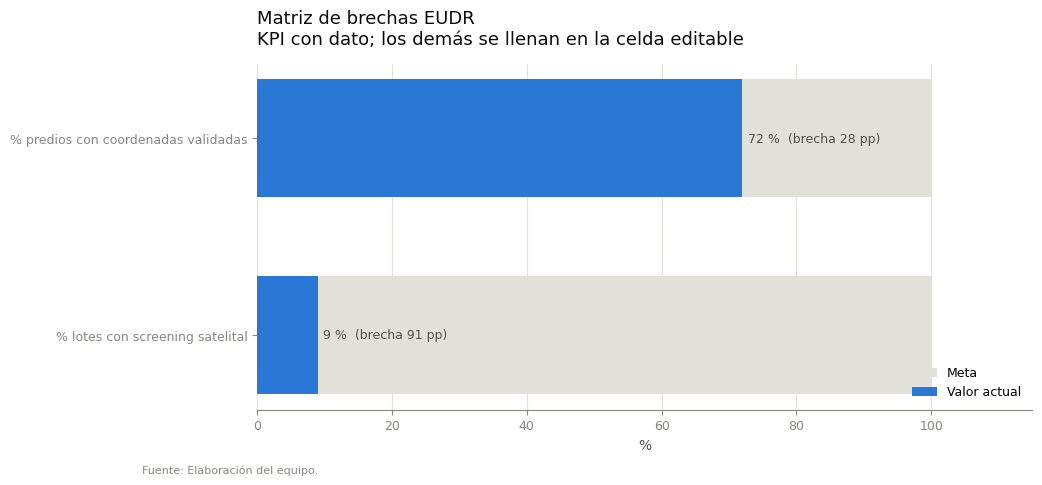

Figura guardada en salidas/g5_matriz_brechas.png


,kpi,requisito_eudr,valor_actual_pct,meta_2026_pct,fuente,brecha_pct
0,% predios con coordenadas validadas,Geolocalización,72.0000,100,USDA FAS 2024,28.0000
1,% lotes con screening satelital,Cero deforestación,9.0000,100,Base del equipo,91.0000
2,% predios con expediente legal completo,Legalidad,NaN,100,,NaN
3,% lotes con ID único / trazabilidad,Trazabilidad,NaN,100,,NaN
4,% evidencias de cero deforestación completas,Cero deforestación,NaN,100,,NaN
5,% registros auditables,Trazabilidad,NaN,100,,NaN


In [20]:
# ====================== EDITABLE: matriz de brechas EUDR (valor actual y meta, en %) ======================
BRECHAS = pd.DataFrame({
    "kpi": ["% predios con coordenadas validadas", "% lotes con screening satelital", "% predios con expediente legal completo",
            "% lotes con ID único / trazabilidad", "% evidencias de cero deforestación completas", "% registros auditables"],
    "requisito_eudr": ["Geolocalización", "Cero deforestación", "Legalidad", "Trazabilidad", "Cero deforestación", "Trazabilidad"],
    "valor_actual_pct": [72, 9, np.nan, np.nan, np.nan, np.nan],
    "meta_2026_pct":    [100, 100, 100, 100, 100, 100],
    "fuente": ["USDA FAS 2024", "Base del equipo", "", "", "", ""],
})
# ==========================================================================================================
BRECHAS["brecha_pct"] = BRECHAS["meta_2026_pct"] - BRECHAS["valor_actual_pct"]
exportar(BRECHAS, "g5_matriz_brechas")
con_dato = BRECHAS.dropna(subset=["valor_actual_pct"])
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(con_dato["kpi"][::-1], con_dato["meta_2026_pct"][::-1], color=REJILLA, height=0.6, label="Meta")
ax.barh(con_dato["kpi"][::-1], con_dato["valor_actual_pct"][::-1], color=AZUL, height=0.6, label="Valor actual")
for y, (v, b) in enumerate(zip(con_dato["valor_actual_pct"][::-1], con_dato["brecha_pct"][::-1])):
    ax.annotate(f"{v:.0f} %  (brecha {b:.0f} pp)", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
ax.set_xlim(0, 115)
ax.legend(frameon=False, fontsize=9, loc="lower right")
estilo(ax, "Matriz de brechas EUDR", "KPI con dato; los demás se llenan en la celda editable", "Elaboración del equipo.", eje_x="%", rejilla="x")
guardar(fig, "g5_matriz_brechas")
BRECHAS

**Análisis del equipo:** ¿Cuáles KPI son críticos antes del 30 de diciembre de 2026 y cuáles pueden esperar a la declaración simplificada de junio de 2027?

_(El diagnóstico de preparación frente al EUDR muestra un patrón desigual dentro del propio sector cacaotero  Colombia tiene una base relativamente sólida en indicadores estructurales ya que el 81% de los productores cacaoteros está dentro de la Frontera Agrícola Nacional y el 72% de los predios ya cuenta con georreferenciación, pero se desploma en el requisito que es el núcleo mismo del reglamento europeo: solo el 9% de los predios ha sido analizado con algún nivel de riesgo de deforestación mediante screening satelital, frente a la meta del 100% exigida para 2026. Esta es, por lejos, la brecha más amplia detectada 91 puntos porcentuales, frente a 28 pp en el indicador de coordenadas validadas, y corresponde exactamente al tipo de evidencia "cero deforestación" que el EUDR exige verificar antes de aceptar una importación. La comparación con el café incluida como referente doméstico, no como dato de cacao, confirma que esta brecha no es un límite de capacidad institucional del país: el sector cafetero ya alcanzó 100% de cobertura de georreferenciación de su parque nacional, 93% de caficultores con autorización de georreferenciación y más de 30.000 productores capacitados específicamente en la regulación EUDR, al punto que la Organización Internacional del Café ubica a Colombia entre los tres orígenes cafeteros mejor preparados para la norma. Esto significa que el país ya tiene un modelo funcional y probado para cumplir este tipo de exigencia el del café, pero ese conocimiento aún no se ha trasladado al cacao, cuyo proceso de trazabilidad satelital apenas comienza. Dado que el EUDR entra en vigor en diciembre de 2026 y aplica directamente a los mercados que este proyecto ya identificó como prioritarios (Países Bajos, Bélgica, Alemania), esta brecha representa un riesgo real y con fecha límite para la estrategia de mercado recomendada: sin evidencia satelital de cero deforestación, el acceso a esos compradores podría verse bloqueado independientemente de la ventaja comparativa o de calidad ya demostrada en los análisis anteriores. La decisión de negocio que esto habilita es incorporar, como parte de la hoja de ruta de recomendaciones, una línea de acción específica y urgente: replicar en el sector cacaotero la metodología de georreferenciación y capacitación que la Federación Nacional de Cafeteros ya implementó exitosamente para el café, priorizando los predios que alimentan la cadena exportadora hacia la Unión Europea.)_

***
# 9. Benchmarking

La matriz benchmark (Colombia frente a Ecuador, Perú y el referente del café) es cualitativa y se construye con las evidencias anteriores. No lleva código.

**Matriz benchmark del equipo:**

_(Colombia es el único de los tres países con una ventaja comparativa matemáticamente robusta y un precio unitario superior al promedio mundial, pero es también el que concentra más su cartera de compradores y el que está más atrasado en preparación regulatoria una combinación de "buen producto, mala gestión del riesgo comercial y regulatorio" que no se ve con la misma intensidad en Ecuador ni Perú. El benchmark posiciona a Colombia como el competidor de mayor potencial cualitativo pero también el de mayor vulnerabilidad estructural del grupo.)_

***
# Entrega

1. Revisa que todas las celdas **Análisis del equipo** tengan texto.  
2. `Archivo → Descargar → Descargar .ipynb`.  
3. Sube el archivo al aula virtual. Las figuras y tablas de `salidas/` pueden ir al informe escrito.

# Referencias

Balassa, B. (1965). Trade liberalisation and "revealed" comparative advantage. *The Manchester School, 33*(2), 99–123.

Vollrath, T. L. (1991). A theoretical evaluation of alternative trade intensity measures of revealed comparative advantage. *Weltwirtschaftliches Archiv, 127*(2), 265–280.

International Trade Centre. (2025). *Trade Map: Trade statistics for international business development*. https://www.trademap.org

Durán Lima, J. E. (s.f.). *Indicadores de comercio exterior y política comercial: Generalidades metodológicas e indicadores básicos*. CEPAL.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55


::: {.pie-ean}
**Equipo 2 · Cacao en grano · HS 1801** · Proyecto final de Inteligencia en Negocios Globales, Universidad EAN, septiembre de 2026. Docente: Alejandra Otero. Sitio construido con [Quarto](https://quarto.org) a partir del cuaderno de análisis del equipo.
:::
